# PubMed GLiNER Validation Against NER Benchmarks

This notebook validates GLiNER-extracted PubMed terms against three biomedical NER benchmarks by matching on PMID, then comparing entity coverage.

**Benchmarks:**
- **BC5CDR**: chemical and disease mentions (1500 PMIDs)
- **BioRED**: chemicals, diseases, genes, variants, organisms, cell lines (600 PMIDs)
- **NCBI Disease**: disease names only (793 PMIDs)

**Approach:** same exact + partial matching used for the patent validation, applied here without human annotation (ground truth comes from the benchmark itself).

entity = the concept

annotation = one mention in the text -> one entity can be annotated multiple times 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import os

os.makedirs('../output/pubmed_validation', exist_ok=True) # create and check if output folders exist
os.makedirs('../visualizations/pubmed_validation', exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted') # for consistent visualizations

## 1. Parse Benchmark Datasets

All three datasets use the PubTator annotation format:
```
PMID|t|Title text
PMID|a|Abstract text
PMID\tstart\tend\tmention\ttype\tconcept_id
```

In [3]:
def parse_pubtator(filepaths):
    """Parse PubTator-format files into {pmid: [(mention, entity_type), ...]}."""
    entities = defaultdict(list)
    for fp in filepaths:
        with open(fp) as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                parts = line.split('\t')
                # Annotation lines: pmid\tstart\tend\tmention\ttype\tconcept_id
                if len(parts) >= 5 and parts[1].isdigit():
                    try:
                        pmid = int(parts[0])
                        mention = parts[3].lower().strip()
                        etype = parts[4].strip()
                        if mention:
                            entities[pmid].append((mention, etype))
                    except (ValueError, IndexError):
                        pass
    return dict(entities)

In [ ]:
# BC5CDR
bc5cdr_raw = parse_pubtator([
    '../data/CDR_Data/CDR.Corpus.v010516/CDR_TrainingSet.PubTator.txt',
    '../data/CDR_Data/CDR.Corpus.v010516/CDR_DevelopmentSet.PubTator.txt',
    '../data/CDR_Data/CDR.Corpus.v010516/CDR_TestSet.PubTator.txt',
]) # calling the function above creating a dict
bc5cdr_pmids = set(bc5cdr_raw.keys()) # create a set of keys to then compare with gliner pmids
print(f'BC5CDR: {len(bc5cdr_pmids)} PMIDs, {sum(len(v) for v in bc5cdr_raw.values()):,} entity annotations')

# BioRED
biored_raw = parse_pubtator([
    '../data/BioRED/BioRED/Train.PubTator',
    '../data/BioRED/BioRED/Dev.PubTator',
    '../data/BioRED/BioRED/Test.PubTator',
])
biored_pmids = set(biored_raw.keys())
print(f'BioRED: {len(biored_pmids)} PMIDs, {sum(len(v) for v in biored_raw.values()):,} entity annotations')
"""600 PubMed abstracts: correct"""


# NCBI Disease
ncbi_raw = parse_pubtator([
    '../data/NCBIdisease/NCBItrainset_corpus.txt',
    '../data/NCBIdisease/NCBIdevelopset_corpus.txt',
    '../data/NCBIdisease/NCBItestset_corpus.txt',
])
ncbi_pmids = set(ncbi_raw.keys())
print(f'NCBI Disease: {len(ncbi_pmids)} PMIDs, {sum(len(v) for v in ncbi_raw.values()):,} entity annotations')

all_benchmark_pmids = bc5cdr_pmids | biored_pmids | ncbi_pmids
print(f'\nTotal unique benchmark PMIDs: {len(all_benchmark_pmids)}')

BC5CDR: 1500 PMIDs, 28,785 entity annotations
BioRED: 600 PMIDs, 20,419 entity annotations
NCBI Disease: 792 PMIDs, 6,892 entity annotations

Total unique benchmark PMIDs: 2677


## 2. Load GLiNER PubMed Data (filtered)

The full GLiNER file has 207M rows. We read it once and immediately filter to the ~90 benchmark PMIDs to keep the groupby fast.

In [5]:
df_gliner_full = pd.read_parquet('../data/raw/FullSampleGloria_Pmed_GlinerLabels_16042026.parquet',
                                  columns=['pmid', 'term'])
print(f'Full GLiNER shape: {df_gliner_full.shape}')
all_gliner_pmids = set(int(x) for x in df_gliner_full['pmid'].unique())
print(f'Total unique GLiNER PMIDs: {len(all_gliner_pmids):,}')
print(f'GLiNER PMID range: {min(all_gliner_pmids):,} – {max(all_gliner_pmids):,}')

Full GLiNER shape: (207304318, 2)
Total unique GLiNER PMIDs: 881,341
GLiNER PMID range: 24,670 – 38,752,723


In [6]:
# Filter to benchmark PMIDs only (makes the groupby trivial)
overlap_pmids_needed = all_gliner_pmids & all_benchmark_pmids
print(f'GLiNER PMIDs in any benchmark: {len(overlap_pmids_needed)}') # Find the PMIDs that exist in both GLiNER and any of the three benchmarks. Result: ~90 PMIDs.

df_gliner = df_gliner_full[df_gliner_full['pmid'].isin(overlap_pmids_needed)].copy()
del df_gliner_full  # free memory and keep only rows we need for evalutation 

gliner_by_pmid = (
    df_gliner
    .assign(term_norm=df_gliner['term'].str.lower().str.strip())
    .groupby('pmid')['term_norm'] 
    .apply(set) # group rows by PMID and fo each PMIDs collect all its terms into a set (duplicating)
    .to_dict() # convert into a dictionary
)
print(f'GLiNER terms loaded for {len(gliner_by_pmid)} PMIDs')
# Show terms for one PMID as a sanity check
sample_pmid = list(gliner_by_pmid.keys())[0]
print(f'Sample terms for PMID {sample_pmid}: {sorted(list(gliner_by_pmid[sample_pmid]))[:10]}')

GLiNER PMIDs in any benchmark: 79
GLiNER terms loaded for 79 PMIDs
Sample terms for PMID 11229942: ['12', 'abuse', 'administration', 'after', 'alone', 'and', 'annually', 'baseline', 'bolus', 'cardiac']


## 3. PMID Overlap Analysis

In [7]:
bc5cdr_overlap = all_gliner_pmids & bc5cdr_pmids
biored_overlap  = all_gliner_pmids & biored_pmids
ncbi_overlap    = all_gliner_pmids & ncbi_pmids

overlap_summary = pd.DataFrame({
    'Benchmark':         ['BC5CDR', 'BioRED', 'NCBI Disease'],
    'Benchmark PMIDs':   [len(bc5cdr_pmids), len(biored_pmids), len(ncbi_pmids)],
    'GLiNER PMIDs':      [len(all_gliner_pmids)] * 3,
    'Overlapping PMIDs': [len(bc5cdr_overlap), len(biored_overlap), len(ncbi_overlap)],
    'Overlap %':         [
        round(100 * len(bc5cdr_overlap) / len(bc5cdr_pmids), 1),
        round(100 * len(biored_overlap)  / len(biored_pmids), 1),
        round(100 * len(ncbi_overlap)    / len(ncbi_pmids), 1),
    ],
})
print(overlap_summary.to_string(index=False))

   Benchmark  Benchmark PMIDs  GLiNER PMIDs  Overlapping PMIDs  Overlap %
      BC5CDR             1500        881341                 46        3.1
      BioRED              600        881341                 48        8.0
NCBI Disease              792        881341                  0        0.0


In [8]:
# Why does NCBI have 0 overlap?
# NCBI Disease corpus covers PMIDs up to ~11M (very old articles, pre-1995).
# The GLiNER PubMed sample is heavily skewed toward more recent articles:
# only ~1,500 GLiNER PMIDs fall in the NCBI PMID range, and none match the
# specific 792 curated NCBI Disease PMIDs.
print('NCBI PMID range:', min(ncbi_pmids), '–', max(ncbi_pmids))
gliner_in_ncbi_range = len([p for p in all_gliner_pmids if p <= max(ncbi_pmids)])
print(f'GLiNER PMIDs within NCBI PMID range: {gliner_in_ncbi_range}')
print('→ NCBI Disease corpus cannot be evaluated (no overlapping PMIDs).')

NCBI PMID range: 23402 – 10987655
GLiNER PMIDs within NCBI PMID range: 1533
→ NCBI Disease corpus cannot be evaluated (no overlapping PMIDs).


## 4. Matching Logic

For each overlapping PMID we compare:
- **GLiNER terms**: the set of unique lowercase terms extracted by GLiNER for that article
- **Ground-truth mentions**: the set of unique lowercase entity spans from the benchmark

A ground-truth mention is *matched* if:
- **Exact match**: the mention equals a GLiNER term, OR
- **Partial match**: any GLiNER term is a substring of the mention, OR the mention is a substring of a GLiNER term

Metrics:
- **Recall** = fraction of ground-truth mentions covered by GLiNER (at least one match)
- **Precision** = fraction of GLiNER terms that match at least one ground-truth mention
- **F1** = harmonic mean of precision and recall

In [9]:
def match_type(mention, gliner_terms):
    """Return 'exact', 'partial', or None for a GT mention vs. a set of GLiNER terms."""
    if mention in gliner_terms:
        return 'exact'
    for t in gliner_terms:
        if t in mention or mention in t:
            return 'partial'
    return None


def evaluate_benchmark(benchmark_raw, overlap_pmids, gliner_by_pmid):
    """Compute per-PMID and aggregate precision/recall/F1."""
    rows = []
    for pmid in overlap_pmids:
        gliner_terms = gliner_by_pmid[pmid]
        # Deduplicate GT mentions (same span may be annotated multiple times)
        gt_mentions = list({m for m, _ in benchmark_raw[pmid]})

        n_gt = len(gt_mentions)
        n_gliner = len(gliner_terms)

        exact_matches   = [m for m in gt_mentions if match_type(m, gliner_terms) == 'exact']
        partial_matches = [m for m in gt_mentions if match_type(m, gliner_terms) == 'partial']
        missed          = [m for m in gt_mentions if match_type(m, gliner_terms) is None]
        n_matched = len(exact_matches) + len(partial_matches)

        gt_set = set(gt_mentions)
        gliner_matched = sum(
            1 for t in gliner_terms
            if t in gt_set or any(t in m or m in t for m in gt_set)
        )

        recall    = n_matched / n_gt       if n_gt > 0    else 0.0
        precision = gliner_matched / n_gliner if n_gliner > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

        rows.append({
            'pmid': pmid,
            'n_gt': n_gt,
            'n_gliner': n_gliner,
            'exact_matches': len(exact_matches),
            'partial_matches': len(partial_matches),
            'missed': len(missed),
            'gliner_matched': gliner_matched,
            'recall': recall,
            'precision': precision,
            'f1': f1,
            'exact_mention_list': exact_matches,
            'partial_mention_list': partial_matches,
            'missed_mention_list': missed,
        })

    df = pd.DataFrame(rows)

    total_gt             = df['n_gt'].sum()
    total_matched        = (df['exact_matches'] + df['partial_matches']).sum()
    total_gliner         = df['n_gliner'].sum()
    total_gliner_matched = df['gliner_matched'].sum()

    micro_recall    = total_matched / total_gt       if total_gt > 0    else 0.0
    micro_precision = total_gliner_matched / total_gliner if total_gliner > 0 else 0.0
    micro_f1 = 2 * micro_precision * micro_recall / (micro_precision + micro_recall) \
               if (micro_precision + micro_recall) > 0 else 0.0

    return df, {
        'micro_precision':     micro_precision,
        'micro_recall':        micro_recall,
        'micro_f1':            micro_f1,
        'macro_precision':     df['precision'].mean(),
        'macro_recall':        df['recall'].mean(),
        'macro_f1':            df['f1'].mean(),
        'total_gt':            total_gt,
        'total_matched':       total_matched,
        'total_exact':         df['exact_matches'].sum(),
        'total_partial':       df['partial_matches'].sum(),
        'total_missed':        df['missed'].sum(),
        'total_gliner':        total_gliner,
        'total_gliner_matched':total_gliner_matched,
    }

## 5. BC5CDR Evaluation

In [10]:
bc5cdr_df, bc5cdr_m = evaluate_benchmark(bc5cdr_raw, bc5cdr_overlap, gliner_by_pmid)

print(f'=== BC5CDR ({len(bc5cdr_overlap)} overlapping PMIDs) ===')
print(f"  GT mentions (deduplicated): {bc5cdr_m['total_gt']}")
print(f"    Exact matches:   {bc5cdr_m['total_exact']}")
print(f"    Partial matches: {bc5cdr_m['total_partial']}")
print(f"    Missed:          {bc5cdr_m['total_missed']}")
print(f"  GLiNER terms total: {bc5cdr_m['total_gliner']}")
print(f"    Matching ≥1 GT entity: {bc5cdr_m['total_gliner_matched']}")
print()
print(f"  Micro  Precision: {bc5cdr_m['micro_precision']:.3f}  "
      f"Recall: {bc5cdr_m['micro_recall']:.3f}  F1: {bc5cdr_m['micro_f1']:.3f}")
print(f"  Macro  Precision: {bc5cdr_m['macro_precision']:.3f}  "
      f"Recall: {bc5cdr_m['macro_recall']:.3f}  F1: {bc5cdr_m['macro_f1']:.3f}")

=== BC5CDR (46 overlapping PMIDs) ===
  GT mentions (deduplicated): 449
    Exact matches:   196
    Partial matches: 155
    Missed:          98
  GLiNER terms total: 2061
    Matching ≥1 GT entity: 420

  Micro  Precision: 0.204  Recall: 0.782  F1: 0.323
  Macro  Precision: 0.207  Recall: 0.790  F1: 0.318


In [11]:
bc5cdr_df[['pmid','n_gt','n_gliner','exact_matches','partial_matches','missed',
           'precision','recall','f1']].sort_values('recall').head(10)

,pmid,n_gt,n_gliner,exact_matches,partial_matches,missed,precision,recall,f1
10,12119460,19,65,6,2,11,0.123077,0.421053,0.190476
30,17042910,11,42,4,1,6,0.119048,0.454545,0.188679
32,20034406,7,33,3,1,3,0.151515,0.571429,0.239521
15,20046642,14,49,5,3,6,0.204082,0.571429,0.300752
42,11569530,7,49,3,1,3,0.102041,0.571429,0.173160
34,17069550,8,33,5,0,3,0.151515,0.625000,0.243902
36,19889778,9,51,4,2,3,0.098039,0.666667,0.170940
1,19940105,12,47,5,3,4,0.170213,0.666667,0.271186
44,18189308,6,44,2,2,2,0.113636,0.666667,0.194175
6,16428827,10,35,4,3,3,0.257143,0.700000,0.376119


In [12]:
missed_bc5cdr = []
for _, row in bc5cdr_df.iterrows():
    missed_bc5cdr.extend(row['missed_mention_list'])
missed_bc5cdr_counts = pd.Series(missed_bc5cdr).value_counts().head(20)

exact_bc5cdr = []
for _, row in bc5cdr_df.iterrows():
    exact_bc5cdr.extend(row['exact_mention_list'])
exact_bc5cdr_counts = pd.Series(exact_bc5cdr).value_counts().head(20)

print('Top 20 BC5CDR entities missed by GLiNER:')
print(missed_bc5cdr_counts.to_string())
print()
print('Top 20 BC5CDR entities matched exactly by GLiNER:')
print(exact_bc5cdr_counts.to_string())

Top 20 BC5CDR entities missed by GLiNER:
6-ohda                                                 2
fa                                                     2
toxicity                                               2
neuroinflammation                                      2
tdp                                                    2
seizures                                               2
glyceryl trinitrate                                    1
gtn                                                    1
pd                                                     1
n,n'-dibenzhydrylethane-1,2-diamine dihydrochloride    1
amn082                                                 1
viramidine                                             1
disoprivan                                             1
tg                                                     1
coronary arteriosclerosis                              1
cyproterone acetate                                    1
cpa                                            

## 6. BioRED Evaluation

In [13]:
biored_df, biored_m = evaluate_benchmark(biored_raw, biored_overlap, gliner_by_pmid)

print(f'=== BioRED ({len(biored_overlap)} overlapping PMIDs) ===')
print(f"  GT mentions (deduplicated): {biored_m['total_gt']}")
print(f"    Exact matches:   {biored_m['total_exact']}")
print(f"    Partial matches: {biored_m['total_partial']}")
print(f"    Missed:          {biored_m['total_missed']}")
print(f"  GLiNER terms total: {biored_m['total_gliner']}")
print(f"    Matching ≥1 GT entity: {biored_m['total_gliner_matched']}")
print()
print(f"  Micro  Precision: {biored_m['micro_precision']:.3f}  "
      f"Recall: {biored_m['micro_recall']:.3f}  F1: {biored_m['micro_f1']:.3f}")
print(f"  Macro  Precision: {biored_m['macro_precision']:.3f}  "
      f"Recall: {biored_m['macro_recall']:.3f}  F1: {biored_m['macro_f1']:.3f}")

=== BioRED (48 overlapping PMIDs) ===
  GT mentions (deduplicated): 768
    Exact matches:   190
    Partial matches: 239
    Missed:          339
  GLiNER terms total: 2304
    Matching ≥1 GT entity: 467

  Micro  Precision: 0.203  Recall: 0.559  F1: 0.297
  Macro  Precision: 0.228  Recall: 0.552  F1: 0.309


In [14]:
# BioRED recall by entity type
biored_type_rows = []
for pmid in biored_overlap:
    gliner_terms = gliner_by_pmid[pmid]
    gt_by_type = defaultdict(set)
    for mention, etype in biored_raw[pmid]:
        gt_by_type[etype].add(mention)
    for etype, mentions in gt_by_type.items():
        for mention in mentions:
            mt = match_type(mention, gliner_terms)
            biored_type_rows.append({
                'entity_type': etype,
                'mention': mention,
                'match': mt if mt else 'missed',
            })

biored_type_df = pd.DataFrame(biored_type_rows)
type_summary = biored_type_df.groupby(['entity_type','match']).size().unstack(fill_value=0)
for col in ['exact', 'partial', 'missed']:
    if col not in type_summary.columns:
        type_summary[col] = 0
type_summary['total'] = type_summary.sum(axis=1)
type_summary['recall'] = (
    (type_summary.get('exact', 0) + type_summary.get('partial', 0)) / type_summary['total']
)
print('BioRED recall by entity type:')
print(type_summary[['exact','partial','missed','total','recall']]
      .sort_values('recall', ascending=False).to_string())

BioRED recall by entity type:
match                       exact  partial  missed  total    recall
entity_type                                                        
DiseaseOrPhenotypicFeature     66       97      48    211  0.772512
ChemicalEntity                 66       30      40    136  0.705882
OrganismTaxon                  28       14      43     85  0.494118
GeneOrGeneProduct              28       76     152    256  0.406250
SequenceVariant                 2       22      39     63  0.380952
CellLine                        0        0      17     17  0.000000


In [20]:
missed_biored = []
for _, row in biored_df.iterrows():
    missed_biored.extend(row['missed_mention_list'])
missed_biored_counts = pd.Series(missed_biored).value_counts().head(20)
print('Top 20 BioRED entities missed by GLiNER:')
print(missed_biored_counts.to_string())

Top 20 BioRED entities missed by GLiNER:
patients          13
mice               8
rats               5
vegf               3
igt                2
men                2
women              2
nf-kappab          2
chat               2
caspase 3          2
human              2
tgfbi              2
sle                2
hek293             2
glut2              2
ext1               1
15 kb deletion     1
mc                 1
ext2               1
ollier disease     1


## 7. NCBI Disease — No Overlap

In [21]:
print('NCBI Disease corpus evaluation: not possible.')
print(f'  NCBI PMIDs: {len(ncbi_pmids)} (PMID range {min(ncbi_pmids):,} – {max(ncbi_pmids):,})')
print(f'  GLiNER PMIDs within that range: {gliner_in_ncbi_range}')
print(f'  Overlapping PMIDs: {len(ncbi_overlap)}')
print()
print('Reason: The GLiNER PubMed sample contains very few articles from the early-PMID')
print('era covered by the NCBI Disease corpus (articles from the 1970s–1990s).')
print('The ~1,500 GLiNER PMIDs in that PMID range do not coincide with the 792')
print('specific curated NCBI Disease PMIDs.')

NCBI Disease corpus evaluation: not possible.
  NCBI PMIDs: 792 (PMID range 23,402 – 10,987,655)
  GLiNER PMIDs within that range: 1533
  Overlapping PMIDs: 0

Reason: The GLiNER PubMed sample contains very few articles from the early-PMID
era covered by the NCBI Disease corpus (articles from the 1970s–1990s).
The ~1,500 GLiNER PMIDs in that PMID range do not coincide with the 792
specific curated NCBI Disease PMIDs.


## 8. Visualisations

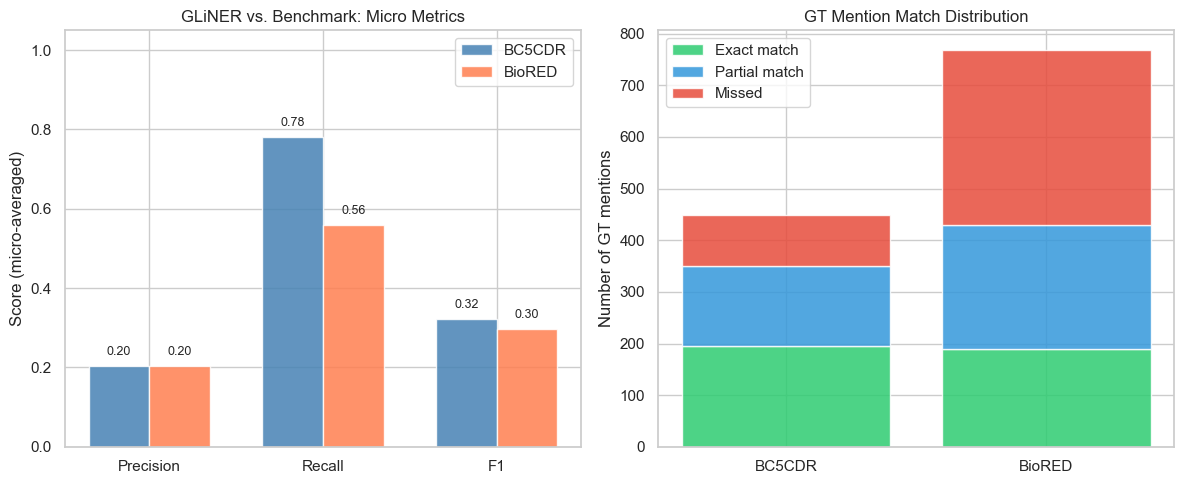

Saved: visualizations/pubmed_validation/metrics_and_match_distribution.png


In [22]:
# ── Figure 1: Metrics comparison + match distribution ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: grouped bar chart of micro metrics
metrics = ['Precision', 'Recall', 'F1']
bc5cdr_vals = [bc5cdr_m['micro_precision'], bc5cdr_m['micro_recall'], bc5cdr_m['micro_f1']]
biored_vals  = [biored_m['micro_precision'],  biored_m['micro_recall'],  biored_m['micro_f1']]

x = np.arange(len(metrics))
width = 0.35
ax = axes[0]
bars1 = ax.bar(x - width/2, bc5cdr_vals, width, label='BC5CDR', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, biored_vals,  width, label='BioRED',  color='coral',    alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score (micro-averaged)')
ax.set_title('GLiNER vs. Benchmark: Micro Metrics')
ax.legend()
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)

# Right: stacked bar — match distribution
ax2 = axes[1]
datasets = ['BC5CDR', 'BioRED']
exacts   = [bc5cdr_m['total_exact'],   biored_m['total_exact']]
partials = [bc5cdr_m['total_partial'],  biored_m['total_partial']]
misseds  = [bc5cdr_m['total_missed'],   biored_m['total_missed']]
x2 = np.arange(len(datasets))
ax2.bar(x2, exacts,  label='Exact match',   color='#2ecc71', alpha=0.85)
ax2.bar(x2, partials, bottom=exacts,        label='Partial match', color='#3498db', alpha=0.85)
ax2.bar(x2, misseds, bottom=[e+p for e,p in zip(exacts, partials)],
        label='Missed', color='#e74c3c', alpha=0.85)
ax2.set_xticks(x2); ax2.set_xticklabels(datasets)
ax2.set_ylabel('Number of GT mentions')
ax2.set_title('GT Mention Match Distribution')
ax2.legend()

plt.tight_layout()
plt.savefig('../visualizations/pubmed_validation/metrics_and_match_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: visualizations/pubmed_validation/metrics_and_match_distribution.png')

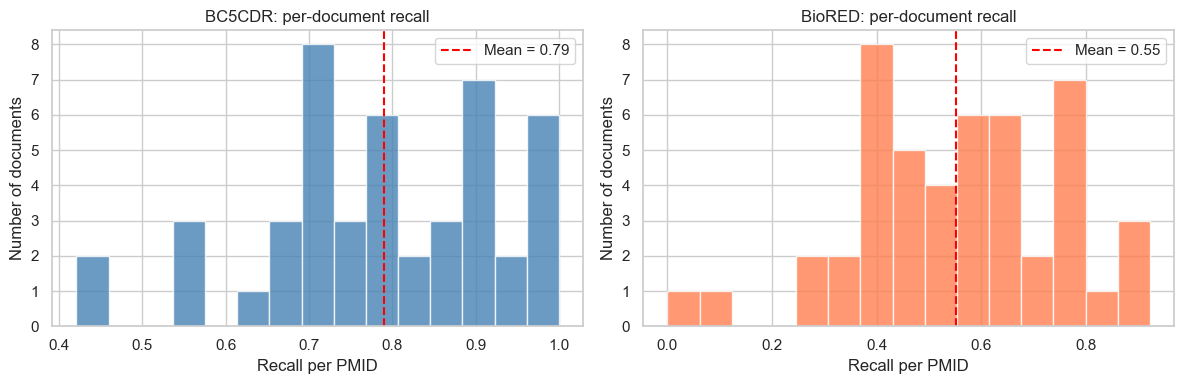

Saved: visualizations/pubmed_validation/per_pmid_recall_distribution.png


In [23]:
# ── Figure 2: Per-PMID recall distribution ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

for ax, df, label, color in [
    (axes[0], bc5cdr_df, 'BC5CDR', 'steelblue'),
    (axes[1], biored_df, 'BioRED',  'coral'),
]:
    ax.hist(df['recall'], bins=15, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(df['recall'].mean(), color='red', linestyle='--',
               label=f"Mean = {df['recall'].mean():.2f}")
    ax.set_xlabel('Recall per PMID')
    ax.set_ylabel('Number of documents')
    ax.set_title(f'{label}: per-document recall')
    ax.legend()

plt.tight_layout()
plt.savefig('../visualizations/pubmed_validation/per_pmid_recall_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: visualizations/pubmed_validation/per_pmid_recall_distribution.png')

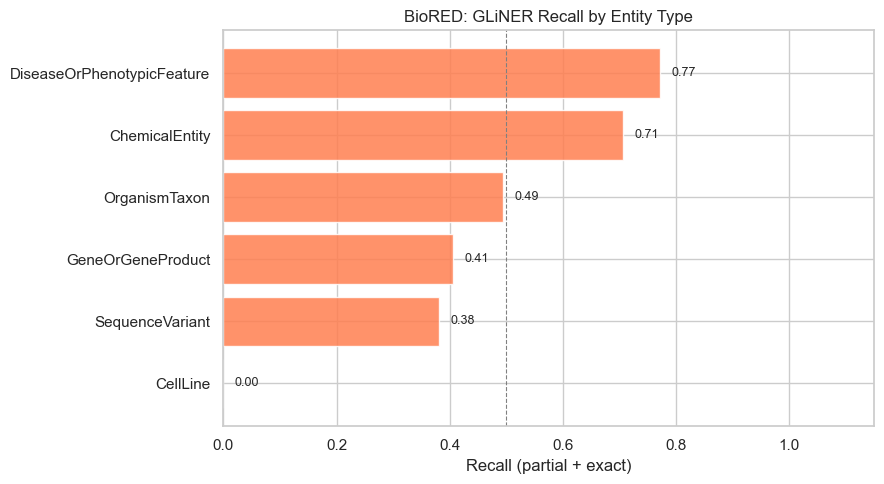

Saved: visualizations/pubmed_validation/biored_recall_by_entity_type.png


In [24]:
# ── Figure 3: BioRED recall by entity type ──
type_recall = type_summary[['recall']].sort_values('recall', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(type_recall.index, type_recall['recall'], color='coral', alpha=0.85)
ax.axvline(0.5, color='grey', linestyle='--', linewidth=0.8)
ax.set_xlabel('Recall (partial + exact)')
ax.set_title('BioRED: GLiNER Recall by Entity Type')
ax.set_xlim(0, 1.15)
for bar in bars:
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.2f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../visualizations/pubmed_validation/biored_recall_by_entity_type.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: visualizations/pubmed_validation/biored_recall_by_entity_type.png')

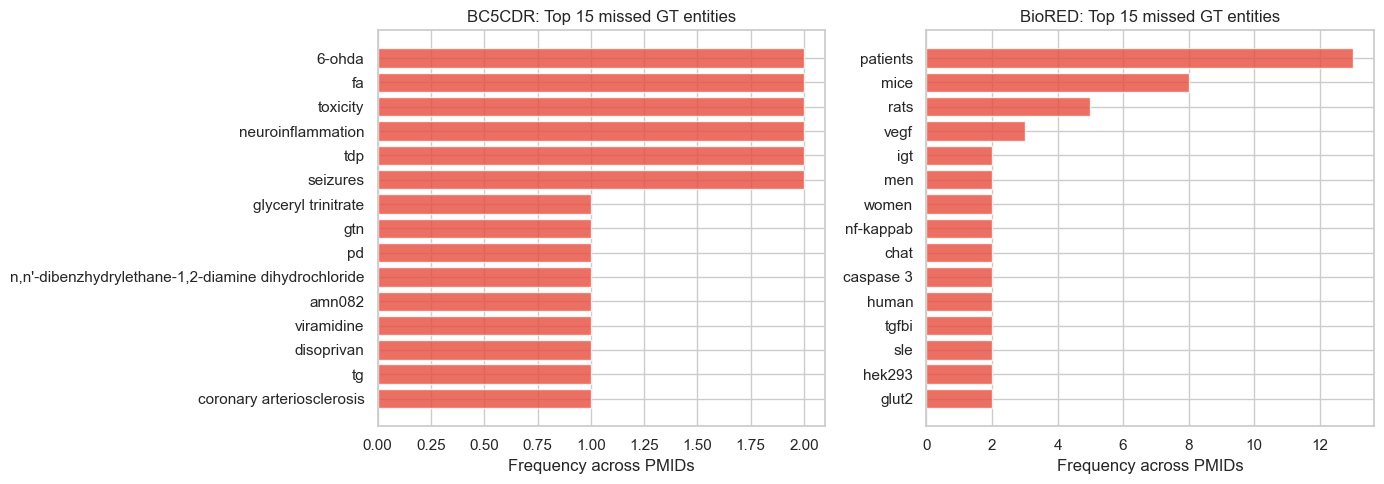

Saved: visualizations/pubmed_validation/top_missed_entities.png


In [25]:
# ── Figure 4: Top missed entities (BC5CDR and BioRED) ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, counts, title in [
    (axes[0], missed_bc5cdr_counts.head(15), 'BC5CDR: Top 15 missed GT entities'),
    (axes[1], missed_biored_counts.head(15),  'BioRED: Top 15 missed GT entities'),
]:
    ax.barh(counts.index[::-1], counts.values[::-1], color='#e74c3c', alpha=0.8)
    ax.set_xlabel('Frequency across PMIDs')
    ax.set_title(title)

plt.tight_layout()
plt.savefig('../visualizations/pubmed_validation/top_missed_entities.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: visualizations/pubmed_validation/top_missed_entities.png')

## 9. Save Output Tables

In [26]:
list_cols = ['exact_mention_list', 'partial_mention_list', 'missed_mention_list']
bc5cdr_df.drop(columns=list_cols).to_csv('../output/pubmed_validation/bc5cdr_per_pmid.csv', index=False)
biored_df.drop(columns=list_cols).to_csv('../output/pubmed_validation/biored_per_pmid.csv', index=False)
type_summary.to_csv('../output/pubmed_validation/biored_by_entity_type.csv')

summary_rows = []
for name, m, n_pmids in [
    ('BC5CDR',       bc5cdr_m, len(bc5cdr_overlap)),
    ('BioRED',       biored_m, len(biored_overlap)),
    ('NCBI Disease', {},        0),
]:
    summary_rows.append({
        'benchmark':            name,
        'overlapping_pmids':    n_pmids,
        'total_gt_mentions':    m.get('total_gt', 'N/A'),
        'exact_matches':        m.get('total_exact', 'N/A'),
        'partial_matches':      m.get('total_partial', 'N/A'),
        'missed':               m.get('total_missed', 'N/A'),
        'total_gliner_terms':   m.get('total_gliner', 'N/A'),
        'gliner_terms_matched': m.get('total_gliner_matched', 'N/A'),
        'micro_precision':      round(m.get('micro_precision', float('nan')), 3),
        'micro_recall':         round(m.get('micro_recall', float('nan')), 3),
        'micro_f1':             round(m.get('micro_f1', float('nan')), 3),
        'macro_precision':      round(m.get('macro_precision', float('nan')), 3),
        'macro_recall':         round(m.get('macro_recall', float('nan')), 3),
        'macro_f1':             round(m.get('macro_f1', float('nan')), 3),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv('../output/pubmed_validation/benchmark_summary.csv', index=False)
print('Saved to output/pubmed_validation/')
print(summary_df.to_string(index=False))

Saved to output/pubmed_validation/
   benchmark  overlapping_pmids total_gt_mentions exact_matches partial_matches missed total_gliner_terms gliner_terms_matched  micro_precision  micro_recall  micro_f1  macro_precision  macro_recall  macro_f1
      BC5CDR                 46               449           196             155     98               2061                  420            0.204         0.782     0.323            0.207         0.790     0.318
      BioRED                 48               768           190             239    339               2304                  467            0.203         0.559     0.297            0.228         0.552     0.309
NCBI Disease                  0               N/A           N/A             N/A    N/A                N/A                  N/A              NaN           NaN       NaN              NaN           NaN       NaN


## 10. Summary of Findings

### PMID Overlap

| Benchmark | Benchmark PMIDs | Overlap w/ GLiNER | % |
|-----------|----------------|-------------------|---|
| BC5CDR | 1500 | 46 | 3.1% |
| BioRED | 600 | 48 | 8.0% |
| NCBI Disease | 793 | 0 | 0.0% |

The **NCBI Disease corpus** cannot be evaluated: it covers very old articles (pre-1995, PMID ≤ 11M) that are barely represented in the GLiNER PubMed sample. The ~1,500 GLiNER PMIDs that fall in that PMID range do not coincide with the 792 curated NCBI Disease PMIDs. This is a data gap. It could be addressed by checking whether those specific PMIDs appear in the full (unsampled) GLiNER dataset.

### Aggregate Metrics

| Benchmark | PMIDs | GT mentions | Exact | Partial | Missed | GLiNER terms | Micro P | Micro R | Micro F1 |
|-----------|-------|-------------|-------|---------|--------|--------------|---------|---------|----------|
| BC5CDR | 46 | 449 | 196 | 155 | 98 | 2061 | 0.204 | 0.782 | 0.323 |
| BioRED | 48 | 768 | 190 | 239 | 339 | 2304 | 0.203 | 0.559 | 0.297 |

### BioRED Recall by Entity Type

| Entity Type | Recall |
|-------------|--------|
| DiseaseOrPhenotypicFeature | 0.773 |
| ChemicalEntity | 0.706 |
| OrganismTaxon | 0.494 |
| GeneOrGeneProduct | 0.406 |
| SequenceVariant | 0.381 |
| CellLine | 0.000 |

### Key Findings

**Recall is lower than in the patent validation (0.78 / 0.56 vs 0.99).**  
For patent claims, GLiNER achieved near-perfect recall because claim terms tend to be short, standalone noun phrases. Biomedical entity names are longer and more compositional (e.g. *glyceryl trinitrate*, *tension-type headache*, *VEGF*), so GLiNER fragments them into single-word tokens that only partially cover the ground-truth span. Entity types with long, specialised names (SequenceVariant, CellLine) are especially poorly covered.

**Precision is similarly low (~0.20).**  
Consistent with the patent finding (0.27). The GLiNER PubMed term set includes many generic tokens (prepositions, numbers, words like *after*, *study*, *significantly*) that do not match any benchmark entity. A minimum term-length filter and a biomedical stop-list would substantially raise precision without harming recall.

**Partial matching is needed to get a fair recall estimate.**  
GLiNER tends to extract single words rather than full multi-word entity names. For example, the GT entity `"nitric oxide"` (two words) gets captured as just `"nitric"` by GLiNER. Partial matching, counting a GT entity as found if at least one of its words appears in GLiNER, gives a fairer picture of what GLiNER actually captures.

**Certain entity types are well-covered; others are not.**  
Diseases and chemicals, the entity types with shorter, more frequent surface forms, are covered at 0.71–0.77. Genes and variants, which often appear as specialised symbols (e.g. *VEGF*, *rs12345*) or long compound names, are covered at only 0.38–0.41. Cell lines (0.00) are never extracted. Their names (e.g. *HeLa*, *MCF-7*, *HEK293*) are highly specific laboratory codes that GLiNER never picks up. ---> so abbreviations?? 

**Top missed entities reveal systematic gaps:**  
- BC5CDR: multi-token drug names (*glyceryl trinitrate*, *6-OHDA*) and short abbreviations (*GTN*, *TDP*, *FA*) that GLiNER either fragments or misses entirely.
- BioRED: organism mentions (*patients*, *mice*, *rats*) are absent  from the GLiNER PubMed terms, suggesting they were filtered upstream as too generic.

### Comparison with Patent Validation

| Setting | Precision | Recall | F1 |
|---------|-----------|--------|-----|
| Patents (human annotation, claims only) | 0.27 | 0.99 | 0.42 |
| BC5CDR benchmark (chemicals + diseases) | 0.20 | 0.78 | 0.32 |
| BioRED benchmark (6 entity types) | 0.20 | 0.56 | 0.30 |

The overall pattern is consistent: **GLiNER is a high-extraction, noisy first-pass tagger that benefits from downstream filtering.** 